# Ce notebook servira a entrainer un modèle que nous n'avons pas programmer nous même mais qu'on utilisera pour comparer nos résultats. C'est un modèle classique de segmentation sémantique qui utilise 5 bandes aussi en entrée. Le notebook est entierement calqué sur celui de model, c'est juste que cette fois ci c'est un modele importé qu'on utilise pour comparer

In [1]:
from pathlib import Path
import json
import numpy as np
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.models.segmentation import deeplabv3_resnet50

from glacier.data.data_fetching import repo_root
from glacier.model import (
    GlacierDataset,
    DiceBCELoss,
    compute_band_stats,
    discover_pairs,
    train_one_epoch,
    evaluate,
    plot_history,
    show_predictions,
)

ROOT = repo_root()

# Hyperparamètres

In [2]:
SEED          = 42
BATCH_SIZE    = 4
EPOCHS        = 100
LR            = 5e-4         # plus bas que le U-Net car backbone pré-entraîné
WEIGHT_DECAY  = 1e-4
PAD_TO        = 320
N_BANDS       = 5

COMPOSITES_ROOT = ROOT / "data" / "sentinel2" / "composites"
MASKS_ROOT      = ROOT / "data" / "sentinel2" / "glims_masks"
CHECKPOINT_DIR  = ROOT / "data" / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
SPLITS_PATH     = CHECKPOINT_DIR / "splits.json"

DEVICE = torch.device("cpu")
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

torch.manual_seed(SEED)
np.random.seed(SEED)

NUM_WORKERS = 0
PIN_MEMORY  = False

Device: cpu


In [3]:
with open(SPLITS_PATH) as f:
    splits = json.load(f)

train_pairs = [(Path(a), Path(b)) for a, b in splits["train"]]
val_pairs   = [(Path(a), Path(b)) for a, b in splits["val"]]
val_regions = splits["val_regions"]

print(f"Train : {len(train_pairs)} paires (Caucase)")
print(f"Val   : {len(val_pairs)} paires (Alpes + Andes mélangés)")
print(f"Détail val : {Counter(val_regions)}")

Train : 346 paires (Caucase)
Val   : 118 paires (Alpes + Andes mélangés)
Détail val : Counter({'alps': 67, 'andes': 51})


In [4]:
# Stats de normalisation depuis le checkpoint U-Net (calculées sur le train)
ckpt_ref = torch.load(CHECKPOINT_DIR / "best_unet.pt", map_location="cpu", weights_only=False)
mean = ckpt_ref["mean"]
std  = ckpt_ref["std"]
print("Mean par bande:", mean)
print("Std  par bande:", std)

Mean par bande: [0.13889991 0.1671084  0.17913195 0.19808231 0.08576448]
Std  par bande: [0.19173633 0.19432458 0.19876385 0.17478466 0.12561154]


In [5]:
train_ds = GlacierDataset(train_pairs, mean, std, augment=True,  pad_to=PAD_TO) # changer ici si on veut augmentation ou pas
val_ds   = GlacierDataset(val_pairs,   mean, std, augment=False, pad_to=PAD_TO)

# Datasets de validation par région
val_pairs_by_region = {}
for pair, reg in zip(val_pairs, val_regions):
    val_pairs_by_region.setdefault(reg, []).append(pair)

val_datasets_by_region = {
    r: GlacierDataset(p, mean, std, augment=False, pad_to=PAD_TO)
    for r, p in val_pairs_by_region.items()
}

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

val_loaders_by_region = {
    r: DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                  num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    for r, ds in val_datasets_by_region.items()
}

print(f"Train : {len(train_ds)} images ({len(train_loader)} batchs)")
print(f"Val   : {len(val_ds)} images ({len(val_loader)} batchs)")

Train : 346 images (87 batchs)
Val   : 118 images (30 batchs)


# Définition du DeepLabV3+

In [13]:
def build_deeplabv3(in_channels: int = 5, pretrained_backbone: bool = True) -> nn.Module:
    """
    DeepLabV3+ avec backbone ResNet50.

    Adaptations pour notre tâche :
    - Première conv : 3 → 5 canaux (poids RGB copiés,
      NIR et SWIR initialisés avec la moyenne des poids RGB).
    - Classifieur de sortie : 21 → 1 (segmentation binaire).
    """
    model = deeplabv3_resnet50(
        weights="DEFAULT" if pretrained_backbone else None,
        num_classes=21,
    )

    # Adapter la première conv pour 5 bandes
    old_conv = model.backbone.conv1
    new_conv = nn.Conv2d(
        in_channels, old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False,
    )
    with torch.no_grad():
        new_conv.weight[:, :3] = old_conv.weight
        mean_w = old_conv.weight.mean(dim=1, keepdim=True)
        for i in range(3, in_channels):
            new_conv.weight[:, i : i + 1] = mean_w
    model.backbone.conv1 = new_conv

    # Tête binaire
    model.classifier[-1] = nn.Conv2d(256, 1, kernel_size=1)
    if hasattr(model, "aux_classifier") and model.aux_classifier is not None:
        model.aux_classifier[-1] = nn.Conv2d(256, 1, kernel_size=1)

    return model


class DeepLabV3Wrapper(nn.Module):
    """
    Wrapper pour que DeepLabV3 ait la même interface que notre UNet.
    Entrée  : (B, 5, H, W)
    Sortie  : (B, 1, H, W) en logits
    """

    def __init__(self, base_model: nn.Module):
        super().__init__()
        self.base_model = base_model

    def forward(self, x):
        out = self.base_model(x)["out"]
        if out.shape[2:] != x.shape[2:]:
            out = nn.functional.interpolate(
                out, size=x.shape[2:], mode="bilinear", align_corners=False
            )
        return out

In [14]:
base_model = build_deeplabv3(in_channels=N_BANDS, pretrained_backbone=True)
model = DeepLabV3Wrapper(base_model).to(DEVICE)

# Vérification des dimensions
model.eval()
dummy = torch.randn(1, N_BANDS, PAD_TO, PAD_TO, device=DEVICE)
out = model(dummy)
print(f"Entrée  : {tuple(dummy.shape)}")
print(f"Sortie  : {tuple(out.shape)}")

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Paramètres entraînables : {n_params:,}")

Entrée  : (1, 5, 320, 320)
Sortie  : (1, 1, 320, 320)
Paramètres entraînables : 42,000,066


# Entrainement

In [15]:
criterion = DiceBCELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

history = {"train_loss": [], "val_loss": [], "train_iou": [], "val_iou": [], "lr": []}
best_val_iou = 0.0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_iou = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss,   val_iou   = evaluate(model, val_loader, criterion, DEVICE)
    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)
    history["lr"].append(current_lr)

    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save({
            "epoch": epoch,
            "model_state_dict": base_model.state_dict(),  # sans le wrapper
            "optimizer_state_dict": optimizer.state_dict(),
            "val_iou": val_iou,
            "mean": mean,
            "std": std,
        }, CHECKPOINT_DIR / "best_deeplabv3.pt")

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:3d}/{EPOCHS} | "
            f"train loss {train_loss:.4f}  IoU {train_iou:.3f} | "
            f"val loss {val_loss:.4f}  IoU {val_iou:.3f} | "
            f"lr {current_lr:.2e}"
        )

print(f"\nMeilleur IoU validation : {best_val_iou:.4f}")

KeyboardInterrupt: 

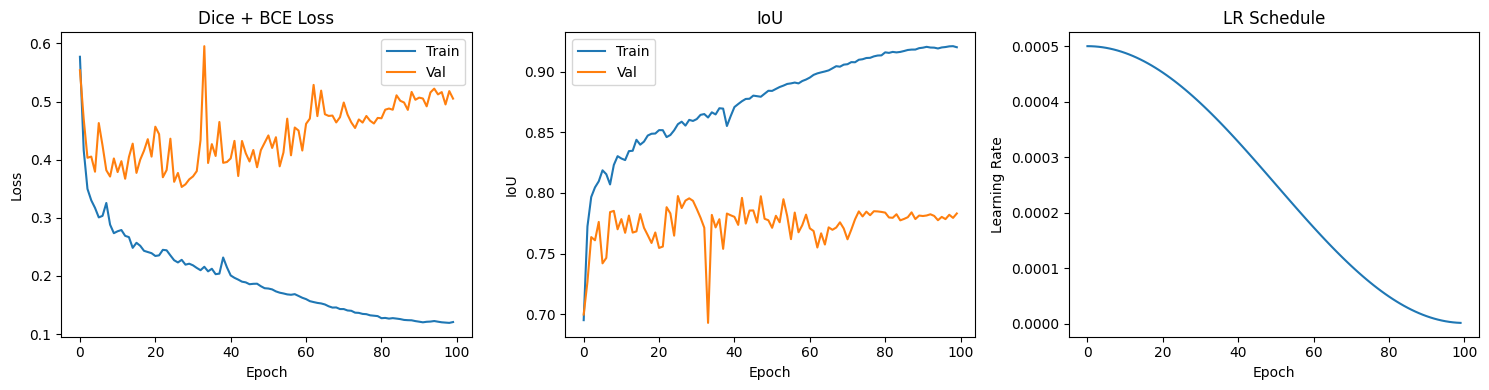

In [9]:
plot_history(history)

# Observons les performances sur l'ensemble de validation maintenant

In [10]:
ckpt = torch.load(CHECKPOINT_DIR / "best_deeplabv3.pt", map_location=DEVICE, weights_only=False)
base_model.load_state_dict(ckpt["model_state_dict"])
model = DeepLabV3Wrapper(base_model).to(DEVICE)
model.eval()
print(f"Checkpoint chargé (epoch {ckpt['epoch']}, val IoU {ckpt['val_iou']:.4f})")

print("\n── Résultats validation globaux ──")
val_loss, val_iou = evaluate(model, val_loader, criterion, DEVICE)
print(f"  {'val (global)':20s} | loss {val_loss:.4f} | IoU {val_iou:.4f}")

print("\n── Résultats par région (validation) ──")
for region, loader in val_loaders_by_region.items():
    if len(loader.dataset) == 0:
        print(f"  {region:20s} | aucune donnée")
        continue
    r_loss, r_iou = evaluate(model, loader, criterion, DEVICE)
    print(f"  {region:20s} | loss {r_loss:.4f} | IoU {r_iou:.4f}")

Checkpoint chargé (epoch 26, val IoU 0.7975)

── Résultats validation globaux ──
  val (global)         | loss 0.3619 | IoU 0.7975

── Résultats par région (validation) ──
  andes                | loss 0.3558 | IoU 0.8130
  alps                 | loss 0.3665 | IoU 0.7857


── Prédictions validation ──


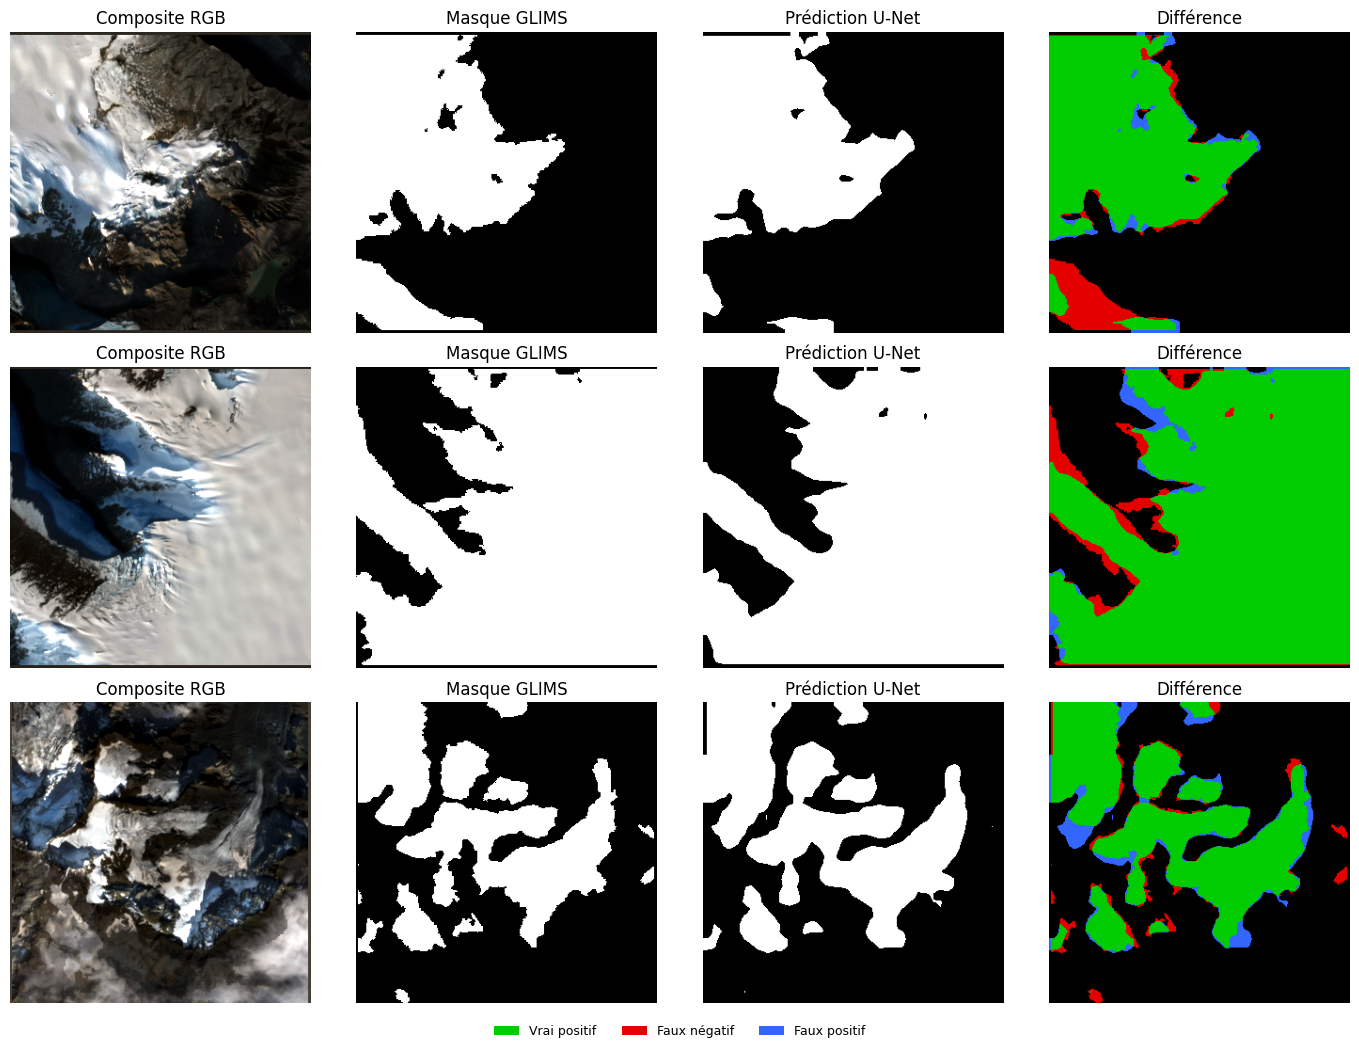


── Prédictions val (andes) ──


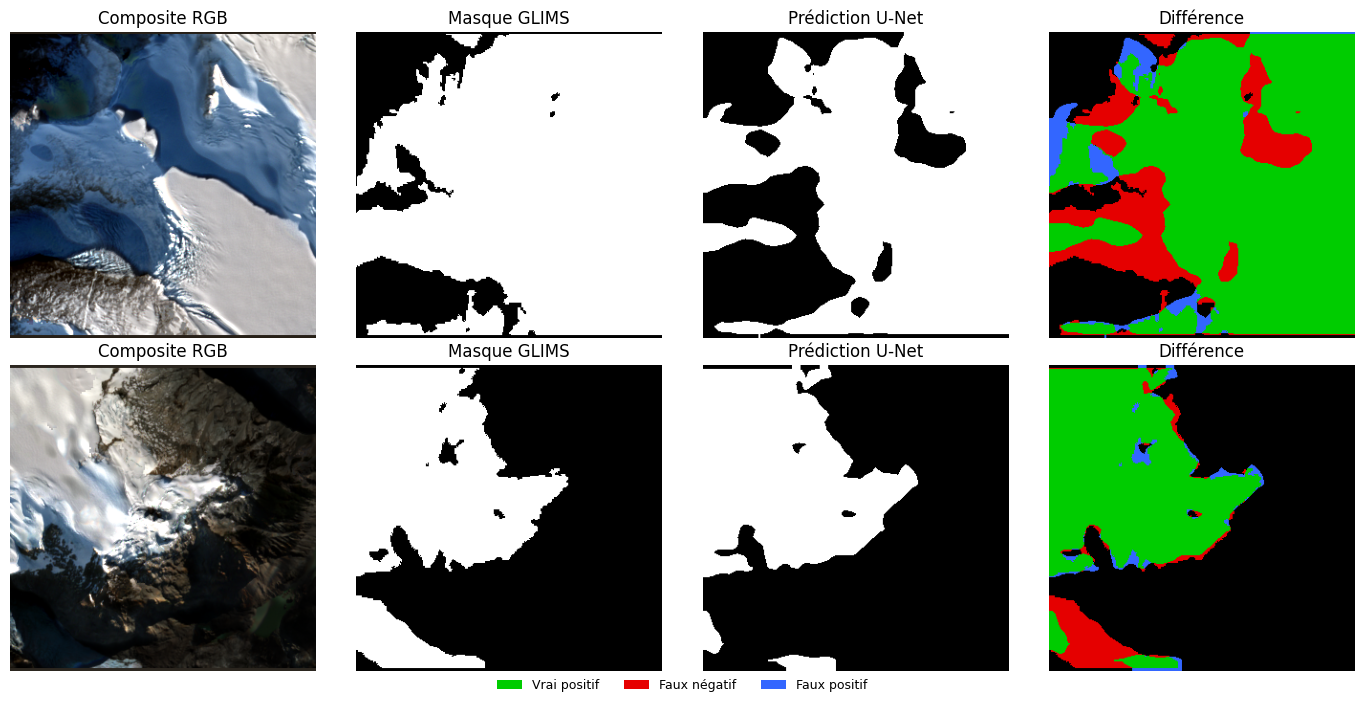


── Prédictions val (alps) ──


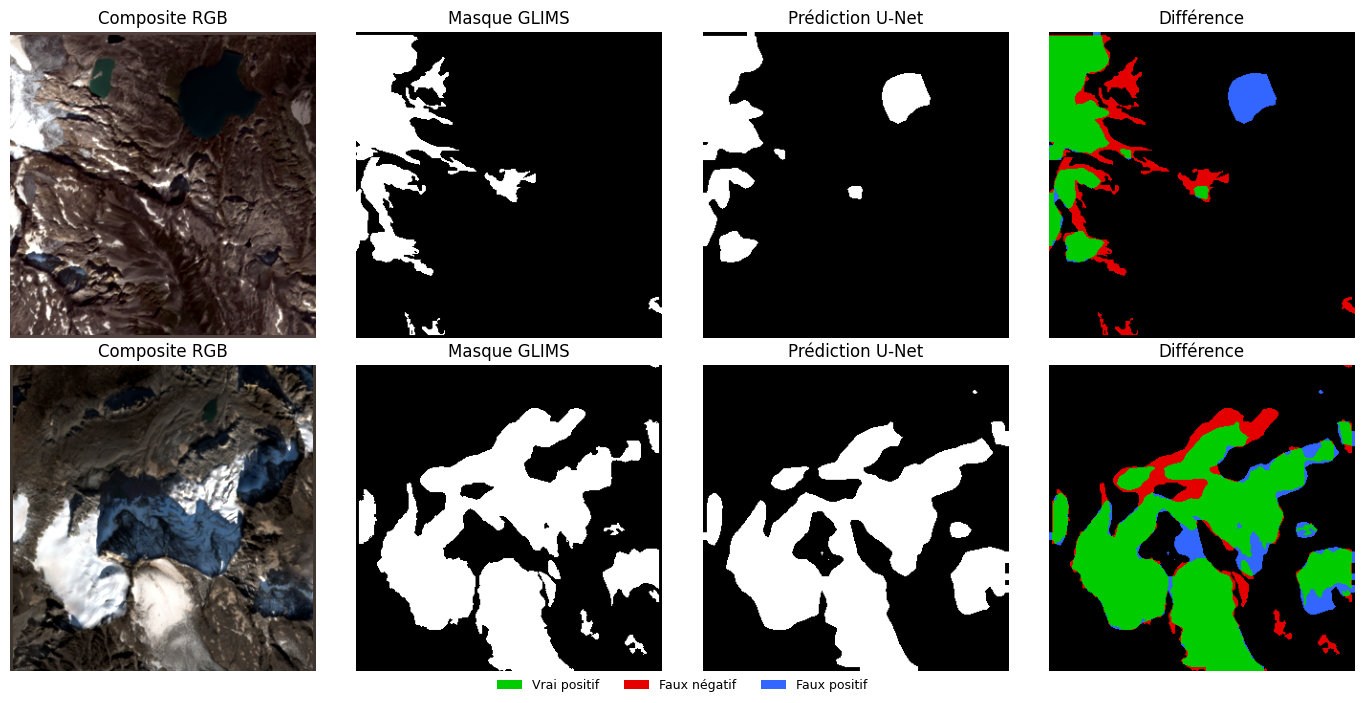

In [11]:
print("── Prédictions validation ──")
show_predictions(model, val_ds, DEVICE, n=3)

for region, ds in val_datasets_by_region.items():
    if len(ds) > 0:
        print(f"\n── Prédictions val ({region}) ──")
        show_predictions(model, ds, DEVICE, n=2)

# Sauvegarde du modèle
## Les modèles sauvegardés seront testé dans le notebook de test

In [12]:
torch.save({
    "model_state_dict": base_model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),
    "epoch": EPOCHS,
    "history": history,
    "best_val_iou": best_val_iou,
    "mean": mean,
    "std": std,
    "config": {
        "in_channels": N_BANDS,
        "backbone": "resnet50",
        "pad_to": PAD_TO,
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
    },
}, CHECKPOINT_DIR / "deeplabv3_final.pt")

print("Modèle sauvegardé dans", CHECKPOINT_DIR / "deeplabv3_final.pt")

Modèle sauvegardé dans C:\Users\Pierre Emery\Documents\Projets\ift3710\projet_glacier\data\checkpoints\deeplabv3_final.pt
